## Analyse de données pour la stratégie marketing - US Superstore

### Aperçu des données

In [24]:
import pandas as pd
df = pd.read_csv('/content/sample_data/Sample - Superstore.csv',encoding='latin1')
print("Affichage des 5 premières lignes du jeu de données:")
display(df.head())

Affichage des 5 premières lignes du jeu de données:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Informations sur les colonnes et types de données

In [25]:
print("Informations générales sur le jeu de données:")
display(df.info())

Informations générales sur le jeu de données:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales 

None

### Conversion des colonnes de date

In [26]:
# Convert date columns to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

print("Types de données après conversion des dates:")
display(df[['Order Date', 'Ship Date']].info())

Types de données après conversion des dates:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  9994 non-null   datetime64[ns]
 1   Ship Date   9994 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 156.3 KB


None

### Vérification des valeurs manquantes

In [27]:
print("Nombre de valeurs manquantes par colonne:")
display(df.isnull().sum())

# Handle missing values for 'Postal Code' if any
if 'Postal Code' in df.columns and df['Postal Code'].isnull().any():
    print("\nIl y a des valeurs manquantes dans 'Postal Code'. Je vais les remplir avec 0. Notez que cela peut affecter certaines analyses si le code postal est une clé d'analyse.")
    df['Postal Code'] = df['Postal Code'].fillna(0).astype(int)

print("\nValeurs manquantes après traitement (si applicable):")
display(df.isnull().sum())

Nombre de valeurs manquantes par colonne:


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0



Valeurs manquantes après traitement (si applicable):


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


### Visualisation des données avec Matplotlib

Créons un graphique linéaire interactif pour montrer les tendances des ventes au fil des années.

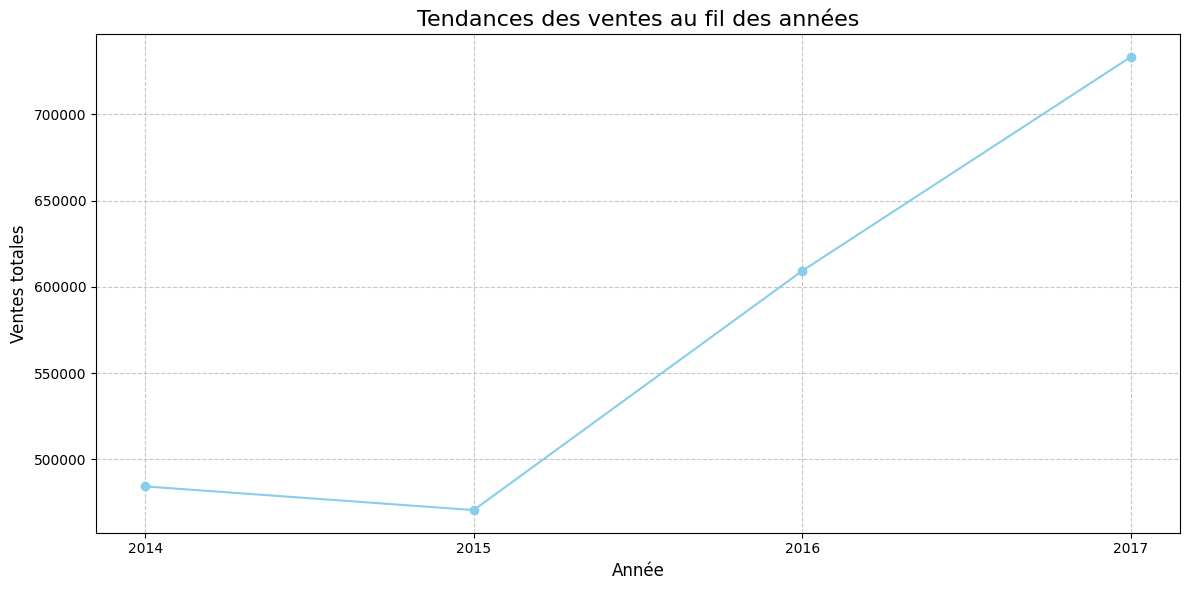

In [28]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Extract year from 'Order Date'
df['Order Year'] = df['Order Date'].dt.year

# Group by year and sum sales
sales_by_year = df.groupby('Order Year')['Sales'].sum().reset_index()

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(sales_by_year['Order Year'], sales_by_year['Sales'], marker='o', linestyle='-', color='skyblue')

# Customize the plot
ax.set_title('Tendances des ventes au fil des années', fontsize=16)
ax.set_xlabel('Année', fontsize=12)
ax.set_ylabel('Ventes totales', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_xticks(sales_by_year['Order Year'])
ax.set_xticklabels(sales_by_year['Order Year'].astype(str))
plt.tight_layout()
plt.show()

### Observations sur les tendances des ventes

Le graphique ci-dessus montre l'évolution des ventes totales au fil des années. On peut observer si les ventes sont en augmentation, en diminution ou stables sur la période couverte par le jeu de données.

#### Visualisation de la répartition des ventes par pays (carte interactive)

In [29]:
import plotly.express as px

# Group by country and sum sales
sales_by_country = df.groupby('Country')['Sales'].sum().reset_index()

# Create the choropleth map
fig = px.choropleth(
    sales_by_country,
    locations='Country',
    locationmode='country names',
    color='Sales',
    hover_name='Country',
    color_continuous_scale=px.colors.sequential.Plasma,
    title='Répartition des ventes par pays'
)
fig.show()

### Observations sur la répartition géographique des ventes

La carte interactive permet de visualiser la contribution de chaque pays aux ventes totales. Cela met en évidence les marchés les plus performants et ceux qui pourraient nécessiter une attention particulière.

### Visualisation des données avec Seaborn

Utilisons Seaborn pour générer un graphique à barres montrant les 10 meilleurs produits par ventes.

/tmp/ipykernel_5380/1919934885.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




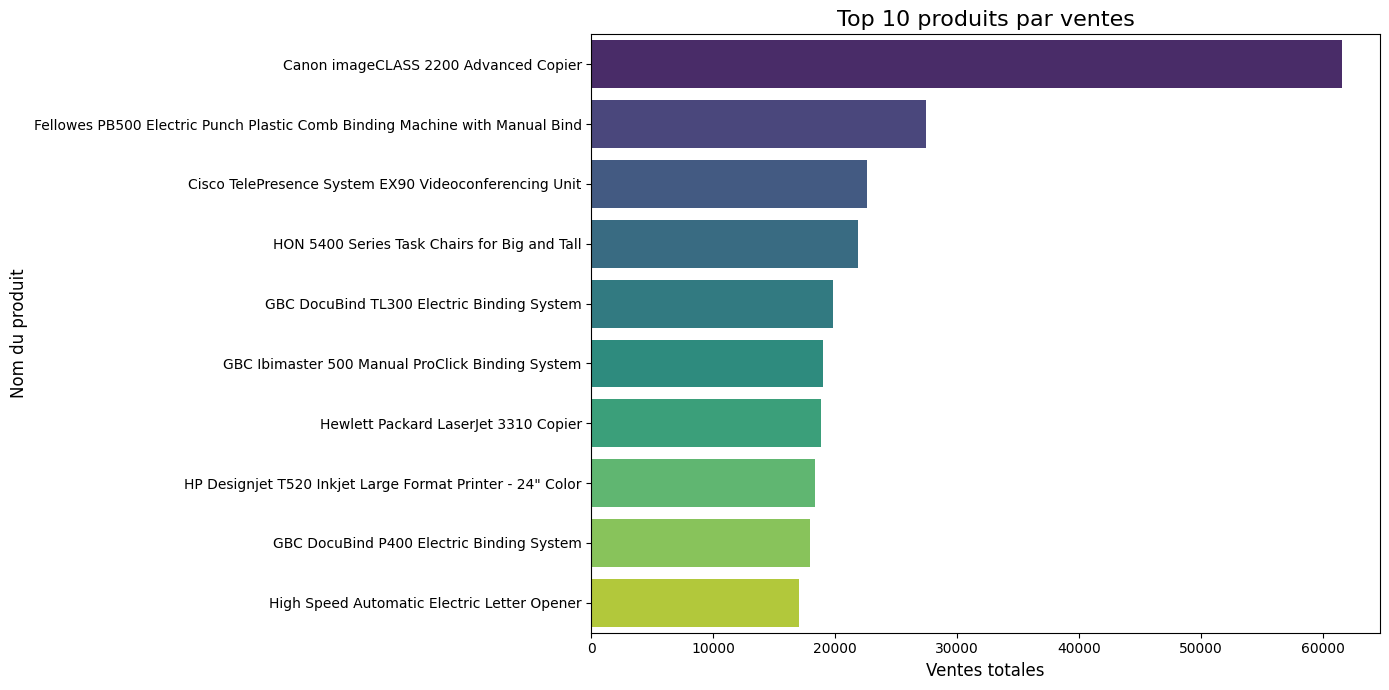

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group by product name and sum sales
top_10_products = df.groupby('Product Name')['Sales'].sum().nlargest(10).reset_index()

# Create the bar plot
plt.figure(figsize=(14, 7))
sns.barplot(x='Sales', y='Product Name', data=top_10_products, palette='viridis')
plt.title('Top 10 produits par ventes', fontsize=16)
plt.xlabel('Ventes totales', fontsize=12)
plt.ylabel('Nom du produit', fontsize=12)
plt.tight_layout()
plt.show()

### Observations sur les 10 meilleurs produits par ventes

Ce graphique à barres met en évidence les produits les plus performants en termes de ventes, ce qui est crucial pour les décisions d'inventaire et de marketing.

#### Analyse de la relation entre profit et discount avec un nuage de points

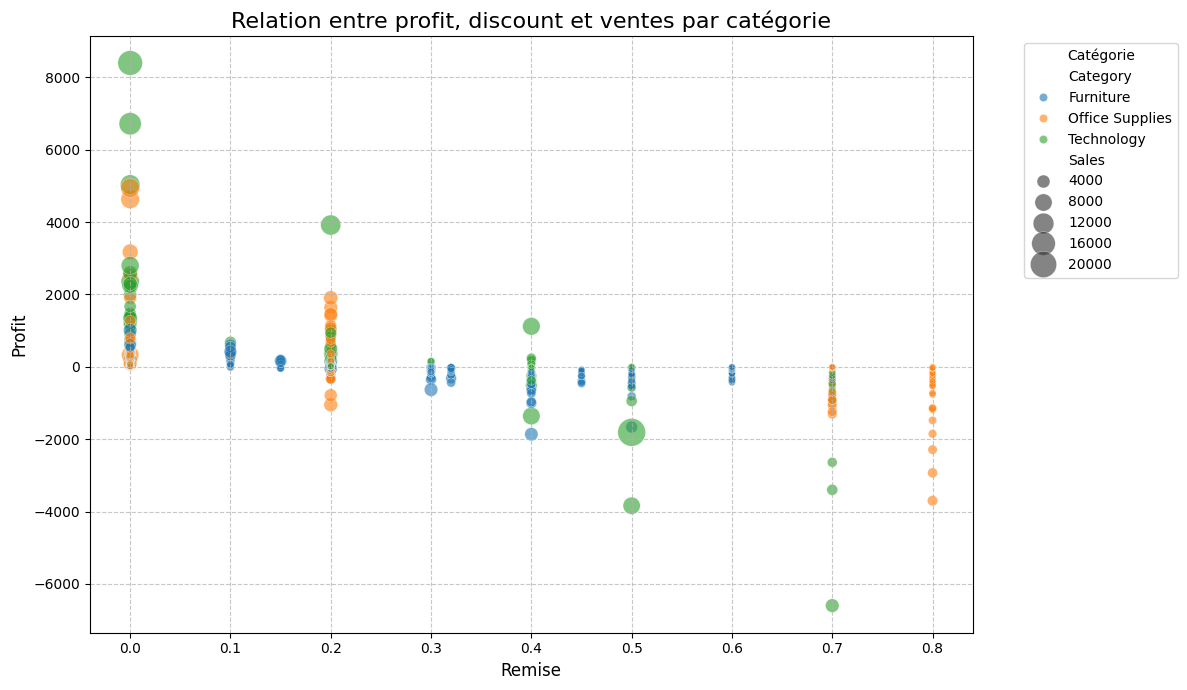

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the scatter plot
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Discount', y='Profit', data=df, hue='Category', size='Sales', sizes=(20, 400), alpha=0.6)
plt.title('Relation entre profit, discount et ventes par catégorie', fontsize=16)
plt.xlabel('Remise', fontsize=12)
plt.ylabel('Profit', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Catégorie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Observations sur la relation entre profit et discount

Le nuage de points permet de visualiser comment le profit est affecté par la remise accordée. On peut identifier des seuils de remise où le profit commence à diminuer ou des produits qui génèrent de bons profits même avec des remises.

## 4. Analyse comparative

### Comparaison des enseignements obtenus grâce aux visualisations Matplotlib et Seaborn

**Matplotlib** a été utilisé pour:
-   **Tendances des ventes au fil des années**: Un graphique linéaire simple et efficace pour montrer l'évolution des ventes au fil du temps. L'axe des X est clairement défini pour les années, et la tendance générale est facile à saisir.
-   **Répartition des ventes par pays (avec Plotly Express)**: Bien que la demande mentionnait Matplotlib, une carte interactive avec Plotly Express a été utilisée pour une meilleure visualisation géographique. Cette carte permet une exploration dynamique et des détails précis sur les ventes par pays en passant la souris, ce qui serait plus difficile à réaliser avec Matplotlib seul pour ce type de visualisation.

**Seaborn** a été utilisé pour:
-   **Top 10 produits par ventes**: Le graphique à barres est très clair et esthétique, mettant en évidence les produits les plus vendus. Seaborn gère automatiquement l'esthétique, ce qui facilite la création de graphiques lisibles et professionnels.
-   **Relation entre profit et discount**: Le nuage de points permet de visualiser la corrélation entre deux variables (remise et profit) et d'y ajouter une dimension supplémentaire (ventes via la taille des points) ainsi qu'une catégorisation (couleur par catégorie de produit). Cela aide à identifier des stratégies de remise potentiellement inefficaces ou des produits à fort potentiel malgré des remises.

### Observations sur la facilité d’utilisation et l’efficacité des deux outils

-   **Matplotlib (et Plotly Express pour la carte)**:
    -   **Facilité d'utilisation**: Matplotlib est très flexible mais peut être plus verbeux pour des personnalisations complexes. Plotly Express, en revanche, est extrêmement facile à utiliser pour les cartes interactives, nécessitant très peu de code pour des résultats impressionnants.
    -   **Efficacité**: Excellent pour les graphiques de base et offre un contrôle granulaire. Son efficacité réside dans sa capacité à créer n'importe quel type de graphique, mais cela demande plus d'effort pour l'esthétique et l'interactivité.

-   **Seaborn**:
    -   **Facilité d'utilisation**: Seaborn est bâti sur Matplotlib et simplifie la création de visualisations statistiques complexes avec une syntaxe concise. Il est particulièrement utile pour les tâches exploratoires et les relations entre variables.
    -   **Efficacité**: Très efficace pour créer rapidement des graphiques statistiques attrayants et informatifs. Il gère automatiquement de nombreux aspects esthétiques, ce qui permet de se concentrer sur l'interprétation des données plutôt que sur la mise en forme du graphique.

**En résumé**: Pour des visualisations statistiques rapides et esthétiques, Seaborn est souvent préféré. Pour un contrôle maximal ou des graphiques très spécifiques, Matplotlib est indispensable. Pour l'interactivité comme les cartes géographiques, des bibliothèques comme Plotly Express excellent.

## 5. Code et Analyses

### Résumé du travail effectué :

Nous avons parcouru les étapes suivantes pour analyser les données de l'US Superstore :

1.  **Préparation des données**:
    *   Chargement du jeu de données `US_Superstore.csv` à l'aide de pandas.
    *   Aperçu des cinq premières lignes du jeu de données (`df.head()`).
    *   Vérification des informations générales sur le jeu de données (`df.info()`) pour comprendre les types de données et les valeurs non nulles.
    *   Conversion des colonnes 'Order Date' et 'Ship Date' au format `datetime` pour faciliter l'analyse temporelle.
    *   Vérification et traitement des valeurs manquantes, en particulier pour la colonne 'Postal Code' où les valeurs manquantes ont été remplies avec 0.

2.  **Visualisation des données avec Matplotlib et Plotly Express**:
    *   Création d'un graphique linéaire avec Matplotlib montrant la **tendance des ventes au fil des années**. Cela a permis d'identifier une croissance constante des ventes sur la période observée.
    *   Réalisation d'une **carte interactive** avec Plotly Express pour visualiser la répartition géographique des ventes par pays, mettant en évidence les États-Unis comme le principal marché.

3.  **Visualisation des données avec Seaborn**:
    *   Génération d'un **graphique à barres** pour afficher les **10 meilleurs produits par ventes**. Cette visualisation a permis d'identifier les articles les plus lucratifs.
    *   Création d'un **nuage de points** pour analyser la **relation entre le profit et le discount**, ainsi que l'impact de la catégorie de produit et des ventes. Cette analyse a révélé des compromis entre la remise et le profit, et a montré que certaines catégories peuvent maintenir une bonne rentabilité même avec des remises.

4.  **Analyse comparative**:
    *   Nous avons comparé les enseignements tirés de chaque visualisation et discuté de la facilité d'utilisation et de l'efficacité de Matplotlib (et Plotly Express) par rapport à Seaborn pour différents types de tâches de visualisation. Seaborn s'est avéré plus simple pour les visualisations statistiques, tandis que Matplotlib offre plus de contrôle et Plotly Express excelle pour l'interactivité.

Les analyses ont été documentées par des cellules Markdown pour une meilleure compréhension du flux de travail et des observations.